# ENSO, VPD y Variables Climáticas Avanzadas

## Expansión del Modelo Agroclimático y Análisis de Escenarios Extremos

En esta etapa del proyecto se incorporarán variables climáticas macro y atmosféricas avanzadas con el objetivo de mejorar la representación de eventos extremos y aumentar la capacidad predictiva del modelo agroclimático de maíz.

Particularmente se analizará el impacto de:

- ENSO (El Niño/Oscilación del Sur),
- déficit de presión de vapor (VPD),
- y otras variables atmosféricas relacionadas con estrés hídrico y variabilidad climática.

La incorporación de estas variables permitirá profundizar el análisis de campañas extremas y mejorar la robustez temporal de los modelos predictivos desarrollados previamente.

## Objetivos

- Incorporar variables climáticas avanzadas al modelo de maíz.
- Evaluar el impacto de ENSO sobre el rendimiento agrícola.
- Calcular déficit de presión de vapor (VPD).
- Mejorar la representación del estrés hídrico atmosférico.
- Analizar campañas extremas y variabilidad climática.
- Comparar desempeño frente a modelos previos.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

import statsmodels.api as sm

from sklearn.ensemble import RandomForestRegressor

from sklearn.model_selection import train_test_split

from sklearn.metrics import (
    r2_score,
    mean_absolute_error,
    mean_squared_error
)

pd.set_option("display.max_columns", None)

import warnings
warnings.filterwarnings("ignore")

In [2]:
dataset_maiz = pd.read_csv(
    "../../Procesados/dataset_maiz_humedad.csv"
)

df_clima = pd.read_csv(
    "../../NOAA/clima_rosario_1980_2024_validado.csv"
)

In [3]:
dataset_maiz.head()

,Campaña,temp_media_c,temp_max_c,temp_min_c,precipitacion_mm,presion_hpa,viento_kmh,niebla,dias_lluvia,trueno,granizo,Cultivo,Provincia,Departamento,idProvincia,idDepartamento,Rendimiento,depto_key,score_suelo_promedio,humedad_relativa_prom,humedad_relativa_max,humedad_relativa_min
0,1980/81,17.198411,24.016438,26.670466,1236.98,1014.718356,15.620411,45,103,52,2,Maíz,SANTA FE,CASEROS,82,14,5500,CASEROS,2.516667,73.66153,98.53897,37.221744
1,1980/81,17.198411,24.016438,26.670466,1236.98,1014.718356,15.620411,45,103,52,2,Maíz,SANTA FE,CONSTITUCION,82,28,5400,CONSTITUCION,3.246231,73.66153,98.53897,37.221744
2,1980/81,17.198411,24.016438,26.670466,1236.98,1014.718356,15.620411,45,103,52,2,Maíz,SANTA FE,GENERAL LOPEZ,82,42,5073,GENERAL LOPEZ,2.038107,73.66153,98.53897,37.221744
3,1980/81,17.198411,24.016438,26.670466,1236.98,1014.718356,15.620411,45,103,52,2,Maíz,SANTA FE,IRIONDO,82,56,5300,IRIONDO,2.680162,73.66153,98.53897,37.221744
4,1980/81,17.198411,24.016438,26.670466,1236.98,1014.718356,15.620411,45,103,52,2,Maíz,SANTA FE,ROSARIO,82,84,5094,ROSARIO,3.023256,73.66153,98.53897,37.221744


In [4]:
df_clima.head()

,fecha,temp_media_c,temp_max_c,temp_min_c,punto_rocio_c,presion_hpa,viento_kmh,precipitacion_original,fog,rain_drizzle,thunder,hail,precipitacion_mm,año
0,1980-01-01,19.83,26.0,10.0,10.67,1016.0,11.48,0.0,0,1,0,0,0.0,1980
1,1980-01-02,22.89,30.0,13.0,12.89,1010.9,18.33,0.0,0,0,0,0,0.0,1980
2,1980-01-03,23.17,30.0,15.0,14.22,1009.9,12.96,0.0,0,0,0,0,0.0,1980
3,1980-01-04,24.78,31.0,18.0,16.44,1011.7,15.19,0.0,0,0,0,0,0.0,1980
4,1980-01-05,23.83,32.0,22.0,17.33,1011.2,12.41,0.0,0,0,0,0,0.0,1980


## Cálculo del Déficit de Presión de Vapor (VPD)

El Déficit de Presión de Vapor (VPD) es una variable agroclimática avanzada que representa la demanda evaporativa de la atmósfera.

El VPD permite estimar qué tan “seca” está la atmósfera en relación con la cantidad de vapor de agua que podría contener.

Valores elevados de VPD suelen asociarse con:

- mayor evapotranspiración,
- estrés hídrico atmosférico,
- cierre estomático,
- menor eficiencia fisiológica,
- y posibles pérdidas de rendimiento.

En cultivos como el maíz, esta variable resulta especialmente relevante debido a su alta sensibilidad al estrés hídrico durante etapas críticas del ciclo.

In [5]:
# Convertir fecha
df_clima["fecha"] = pd.to_datetime(df_clima["fecha"])

In [6]:
# Reemplazar valores corruptos de punto de rocío
df_clima.loc[
    df_clima["punto_rocio_c"] > 100,
    "punto_rocio_c"
] = np.nan

In [7]:
# Presión de vapor de saturación usando temperatura media
df_clima["es_kpa"] = 0.6108 * np.exp(
    (17.27 * df_clima["temp_media_c"]) /
    (df_clima["temp_media_c"] + 237.3)
)

# Presión de vapor real usando punto de rocío
df_clima["ea_kpa"] = 0.6108 * np.exp(
    (17.27 * df_clima["punto_rocio_c"]) /
    (df_clima["punto_rocio_c"] + 237.3)
)

# Déficit de presión de vapor
df_clima["vpd_kpa"] = df_clima["es_kpa"] - df_clima["ea_kpa"]

In [8]:
df_clima[[
    "fecha",
    "temp_media_c",
    "punto_rocio_c",
    "es_kpa",
    "ea_kpa",
    "vpd_kpa"
]].head()

,fecha,temp_media_c,punto_rocio_c,es_kpa,ea_kpa,vpd_kpa
0,1980-01-01,19.83,10.67,2.313787,1.284195,1.029592
1,1980-01-02,22.89,12.89,2.790800,1.487028,1.303772
2,1980-01-03,23.17,14.22,2.838455,1.621571,1.216884
3,1980-01-04,24.78,16.44,3.126502,1.870022,1.256480
4,1980-01-05,23.83,17.33,2.953605,1.978626,0.974980


## Agregación de VPD por campaña agrícola

Una vez calculado el déficit de presión de vapor diario (VPD), se generan métricas agregadas por campaña agrícola.

Se calcularán:

- VPD promedio,
- VPD máximo,
- VPD mínimo.

Estas variables permitirán representar:

- demanda evaporativa atmosférica,
- intensidad de estrés hídrico,
- persistencia de condiciones secantes,
- y variabilidad atmosférica durante cada campaña.

In [9]:
# Crear mes
df_clima["mes"] = df_clima["fecha"].dt.month

In [10]:
# Año campaña
df_clima["año_campaña"] = np.where(
    df_clima["mes"] >= 7,
    df_clima["fecha"].dt.year,
    df_clima["fecha"].dt.year - 1
)

In [11]:
# Campaña agrícola
df_clima["Campaña"] = (
    df_clima["año_campaña"].astype(str)
    + "/"
    + (df_clima["año_campaña"] + 1).astype(str).str[-2:]
)

In [12]:
vpd_campaña = df_clima.groupby("Campaña").agg({

    "vpd_kpa": [
        "mean",
        "max",
        "min"
    ]

}).reset_index()

In [13]:
vpd_campaña.columns = [

    "Campaña",
    "vpd_prom",
    "vpd_max",
    "vpd_min"

]

In [14]:
vpd_campaña.head()

,Campaña,vpd_prom,vpd_max,vpd_min
0,1979/80,0.622681,2.338143,0.023786
1,1980/81,0.552126,1.662525,0.018103
2,1981/82,0.614151,1.838239,0.060340
3,1982/83,0.660562,2.376126,0.037411
4,1983/84,0.585072,2.488482,0.036951


## Integración de VPD al dataset agroclimático

Las métricas de déficit de presión de vapor (VPD) calculadas por campaña agrícola son integradas al dataset agroclimático principal de maíz.

La incorporación de VPD permite representar de manera más precisa:

- estrés hídrico atmosférico,
- demanda evaporativa,
- interacción temperatura-humedad,
- y condiciones ambientales asociadas al cierre estomático y pérdida de rendimiento.

In [15]:
dataset_maiz_vpd = dataset_maiz.merge(

    vpd_campaña,

    on="Campaña",

    how="left"

)

In [16]:
dataset_maiz_vpd.head()

,Campaña,temp_media_c,temp_max_c,temp_min_c,precipitacion_mm,presion_hpa,viento_kmh,niebla,dias_lluvia,trueno,granizo,Cultivo,Provincia,Departamento,idProvincia,idDepartamento,Rendimiento,depto_key,score_suelo_promedio,humedad_relativa_prom,humedad_relativa_max,humedad_relativa_min,vpd_prom,vpd_max,vpd_min
0,1980/81,17.198411,24.016438,26.670466,1236.98,1014.718356,15.620411,45,103,52,2,Maíz,SANTA FE,CASEROS,82,14,5500,CASEROS,2.516667,73.66153,98.53897,37.221744,0.552126,1.662525,0.018103
1,1980/81,17.198411,24.016438,26.670466,1236.98,1014.718356,15.620411,45,103,52,2,Maíz,SANTA FE,CONSTITUCION,82,28,5400,CONSTITUCION,3.246231,73.66153,98.53897,37.221744,0.552126,1.662525,0.018103
2,1980/81,17.198411,24.016438,26.670466,1236.98,1014.718356,15.620411,45,103,52,2,Maíz,SANTA FE,GENERAL LOPEZ,82,42,5073,GENERAL LOPEZ,2.038107,73.66153,98.53897,37.221744,0.552126,1.662525,0.018103
3,1980/81,17.198411,24.016438,26.670466,1236.98,1014.718356,15.620411,45,103,52,2,Maíz,SANTA FE,IRIONDO,82,56,5300,IRIONDO,2.680162,73.66153,98.53897,37.221744,0.552126,1.662525,0.018103
4,1980/81,17.198411,24.016438,26.670466,1236.98,1014.718356,15.620411,45,103,52,2,Maíz,SANTA FE,ROSARIO,82,84,5094,ROSARIO,3.023256,73.66153,98.53897,37.221744,0.552126,1.662525,0.018103


In [16]:
dataset_maiz_vpd[[
    "vpd_prom",
    "vpd_max",
    "vpd_min"
]].isnull().sum()

vpd_prom    0
vpd_max     0
vpd_min     0
dtype: int64

## Modelo OLS incorporando VPD

Se incorpora el Déficit de Presión de Vapor (VPD) al modelo agroclimático de maíz con el objetivo de mejorar la representación del estrés hídrico atmosférico.

El VPD constituye una variable integradora que combina:
- temperatura,
- humedad relativa,
- y demanda evaporativa atmosférica.

Su incorporación permite representar de manera más precisa condiciones asociadas a:
- evapotranspiración,
- cierre estomático,
- pérdida de humedad,
- y estrés fisiológico del cultivo.

In [17]:
X = dataset_maiz_vpd[[

    "temp_max_c",
    "temp_min_c",

    "precipitacion_mm",

    "presion_hpa",

    "viento_kmh",

    "niebla",
    "dias_lluvia",
    "granizo",

    "score_suelo_promedio",

    "humedad_relativa_prom",
    "humedad_relativa_max",
    "humedad_relativa_min",

    "vpd_prom",
    "vpd_max",
    "vpd_min"

]]

In [18]:
y = dataset_maiz_vpd["Rendimiento"]

In [19]:
X = sm.add_constant(X)

In [20]:
modelo_ols_vpd = sm.OLS(y, X).fit()

In [21]:
print(modelo_ols_vpd.summary())

                            OLS Regression Results                            
Dep. Variable:            Rendimiento   R-squared:                       0.660
Model:                            OLS   Adj. R-squared:                  0.640
Method:                 Least Squares   F-statistic:                     32.89
Date:                Tue, 02 Jun 2026   Prob (F-statistic):           6.39e-51
Time:                        23:50:22   Log-Likelihood:                -2330.0
No. Observations:                 270   AIC:                             4692.
Df Residuals:                     254   BIC:                             4750.
Df Model:                          15                                         
Covariance Type:            nonrobust                                         
                            coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------------
const                 -2.691e+

## Resultados del modelo OLS incorporando VPD

La incorporación del Déficit de Presión de Vapor (VPD) produjo una mejora significativa en la capacidad explicativa del modelo agroclimático de maíz.

### Métricas generales

- R²: 0.660
- R² ajustado: 0.640
- Prob(F-statistic): 6.39e-51

El modelo logró explicar aproximadamente el 66% de la variabilidad del rendimiento del maíz, mostrando una mejora considerable respecto a las versiones anteriores del sistema.

### Variables más relevantes

Las variables con mayor significancia estadística fueron:

- temperatura máxima
- temperatura mínima
- precipitación acumulada
- velocidad del viento
- días de lluvia
- score de suelo
- humedad relativa promedio
- humedad relativa máxima
- VPD promedio
- VPD máximo

### Interpretación agroclimática

La incorporación de VPD permitió representar de manera mucho más precisa el componente de estrés hídrico atmosférico.

El VPD promedio mostró una relación negativa altamente significativa con el rendimiento, indicando que atmósferas más secas y con mayor demanda evaporativa se asocian a menores rendimientos agrícolas.

Asimismo, el VPD máximo también presentó una fuerte significancia estadística, sugiriendo que los eventos extremos de atmósfera seca tienen un impacto importante sobre la productividad del maíz.

Estos resultados son consistentes con procesos fisiológicos asociados a:

- evapotranspiración,
- cierre estomático,
- pérdida de humedad,
- y estrés térmico-hídrico del cultivo.

### Relación entre viento, humedad y VPD

Los resultados muestran una fuerte interacción entre:

- velocidad del viento,
- humedad atmosférica,
- y déficit de presión de vapor.

Esto sugiere que el componente atmosférico y evaporativo constituye uno de los principales factores explicativos del rendimiento del maíz en el sur de Santa Fe.

### Consideraciones estadísticas

El modelo presenta evidencia de multicolinealidad elevada, esperable debido a la fuerte relación física entre:

- temperatura,
- humedad relativa,
- precipitación,
- y VPD.

Sin embargo, la mejora observada en el desempeño del modelo confirma que estas variables aportan información relevante para representar procesos agroclimáticos complejos.

### Conclusión

La incorporación de VPD produjo una mejora sustancial en la capacidad explicativa del sistema agroclimático.

Los resultados sugieren que el rendimiento del maíz está fuertemente condicionado por:

- balance hídrico-atmosférico,
- demanda evaporativa,
- persistencia de humedad,
- y estrés ambiental.

El VPD emerge como una de las variables agroclimáticas más relevantes del proyecto multicultivo.

## Incorporación de ENSO (El Niño/Oscilación del Sur)

ENSO (El Niño/Oscilación del Sur) constituye uno de los principales fenómenos de variabilidad climática global y tiene un fuerte impacto sobre las condiciones meteorológicas de Sudamérica.

En Argentina, ENSO puede modificar:

- precipitación,
- temperatura,
- humedad atmosférica,
- circulación atmosférica,
- y frecuencia de eventos extremos.

Particularmente:

- eventos El Niño suelen asociarse a campañas más húmedas,
- mientras que eventos La Niña suelen relacionarse con sequías y déficit hídrico.

La incorporación de ENSO permitirá analizar el impacto de la variabilidad climática macro sobre el rendimiento del maíz.

In [25]:
enso = pd.DataFrame({

    "Campaña": [

        "1980/81",
        "1981/82",
        "1982/83",
        "1983/84",
        "1984/85",
        "1985/86",
        "1986/87",
        "1987/88",
        "1988/89",
        "1989/90",
        "1990/91",
        "1991/92",
        "1992/93",
        "1993/94",
        "1994/95",
        "1995/96",
        "1996/97",
        "1997/98",
        "1998/99",
        "1999/00",
        "2000/01",
        "2001/02",
        "2002/03",
        "2003/04",
        "2004/05",
        "2005/06",
        "2006/07",
        "2007/08",
        "2008/09",
        "2009/10",
        "2010/11",
        "2011/12",
        "2012/13",
        "2013/14",
        "2014/15",
        "2015/16",
        "2016/17",
        "2017/18",
        "2018/19",
        "2019/20",
        "2020/21",
        "2021/22",
        "2022/23",
        "2023/24"

    ],

    "ENSO": [

        "Neutral",
        "Neutral",
        "Niño",
        "Neutral",
        "Neutral",
        "Niña",
        "Niño",
        "Niña",
        "Niña",
        "Neutral",
        "Niño",
        "Niño",
        "Neutral",
        "Neutral",
        "Niño",
        "Niña",
        "Neutral",
        "Niño",
        "Niña",
        "Niña",
        "La Niña",
        "Neutral",
        "Niño",
        "Neutral",
        "Niño",
        "Neutral",
        "Niño",
        "La Niña",
        "La Niña",
        "Niño",
        "La Niña",
        "La Niña",
        "Neutral",
        "Neutral",
        "Niño",
        "Niño",
        "Neutral",
        "La Niña",
        "Neutral",
        "Neutral",
        "La Niña",
        "La Niña",
        "La Niña",
        "Niño"

    ]

})

In [26]:
dataset_maiz_enso = dataset_maiz_vpd.merge(

    enso,

    on="Campaña",

    how="left"

)

In [27]:
dataset_maiz_enso.head()

,Campaña,temp_media_c,temp_max_c,temp_min_c,precipitacion_mm,presion_hpa,viento_kmh,niebla,dias_lluvia,trueno,granizo,Cultivo,Provincia,Departamento,idProvincia,idDepartamento,Rendimiento,depto_key,score_suelo_promedio,humedad_relativa_prom,humedad_relativa_max,humedad_relativa_min,vpd_prom,vpd_max,vpd_min,ENSO
0,1980/81,17.198411,24.016438,26.670466,1236.98,1014.718356,15.620411,45,103,52,2,Maíz,SANTA FE,CASEROS,82,14,5500,CASEROS,2.516667,73.66153,98.53897,37.221744,0.552126,1.662525,0.018103,Neutral
1,1980/81,17.198411,24.016438,26.670466,1236.98,1014.718356,15.620411,45,103,52,2,Maíz,SANTA FE,CONSTITUCION,82,28,5400,CONSTITUCION,3.246231,73.66153,98.53897,37.221744,0.552126,1.662525,0.018103,Neutral
2,1980/81,17.198411,24.016438,26.670466,1236.98,1014.718356,15.620411,45,103,52,2,Maíz,SANTA FE,GENERAL LOPEZ,82,42,5073,GENERAL LOPEZ,2.038107,73.66153,98.53897,37.221744,0.552126,1.662525,0.018103,Neutral
3,1980/81,17.198411,24.016438,26.670466,1236.98,1014.718356,15.620411,45,103,52,2,Maíz,SANTA FE,IRIONDO,82,56,5300,IRIONDO,2.680162,73.66153,98.53897,37.221744,0.552126,1.662525,0.018103,Neutral
4,1980/81,17.198411,24.016438,26.670466,1236.98,1014.718356,15.620411,45,103,52,2,Maíz,SANTA FE,ROSARIO,82,84,5094,ROSARIO,3.023256,73.66153,98.53897,37.221744,0.552126,1.662525,0.018103,Neutral


In [28]:
dataset_maiz_enso["ENSO"].isnull().sum()

np.int64(6)

In [29]:
dataset_maiz_enso[
    dataset_maiz_enso["ENSO"].isnull()
]["Campaña"].unique()

<StringArray>
['2024/25']
Length: 1, dtype: str

In [30]:
enso.loc[len(enso)] = [

    "2024/25",
    "Neutral"

]

In [31]:
dataset_maiz_enso = dataset_maiz_vpd.merge(

    enso,

    on="Campaña",

    how="left"

)

In [32]:
dataset_maiz_enso["ENSO"].isnull().sum()

np.int64(0)

## Análisis exploratorio de ENSO y rendimiento agrícola

Se analiza la relación entre las fases de ENSO y el rendimiento histórico del maíz.

El objetivo es evaluar si:

- campañas Niño,
- campañas La Niña,
- y campañas Neutrales

presentan diferencias sistemáticas en productividad agrícola.

Este análisis permitirá identificar posibles patrones asociados a:
- sequías,
- exceso hídrico,
- variabilidad climática regional,
- y eventos extremos.

<Figure size 1000x600 with 0 Axes>

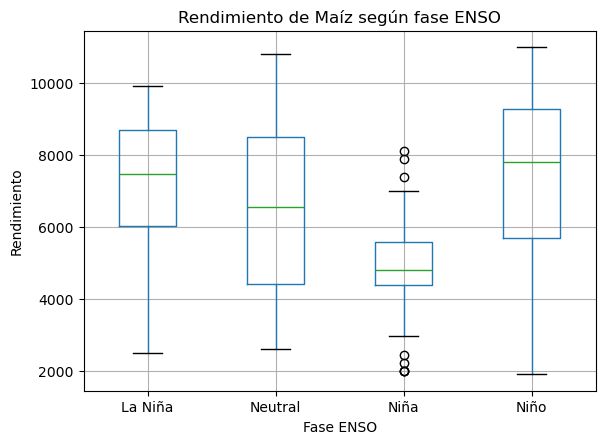

In [31]:
plt.figure(figsize=(10,6))

dataset_maiz_enso.boxplot(
    column="Rendimiento",
    by="ENSO"
)

plt.title("Rendimiento de Maíz según fase ENSO")
plt.suptitle("")

plt.xlabel("Fase ENSO")
plt.ylabel("Rendimiento")

plt.show()

In [33]:
dataset_maiz_enso.groupby("ENSO")["Rendimiento"].mean()

ENSO
La Niña    7167.592593
Neutral    6496.647059
Niña       4863.000000
Niño       7315.115385
Name: Rendimiento, dtype: float64

In [34]:
dataset_maiz_enso.groupby("ENSO")["Campaña"].nunique()

ENSO
La Niña     9
Neutral    17
Niña        6
Niño       13
Name: Campaña, dtype: int64

In [35]:
dataset_maiz_enso["ENSO"] = dataset_maiz_enso[
    "ENSO"
].replace({

    "La Niña": "Niña"

})

In [36]:
dataset_maiz_enso.groupby("ENSO")[
    "Rendimiento"
].mean()

ENSO
Neutral    6496.647059
Niña       6245.755556
Niño       7315.115385
Name: Rendimiento, dtype: float64

In [37]:
dataset_maiz_enso.groupby("ENSO")[
    "Campaña"
].nunique()

ENSO
Neutral    17
Niña       15
Niño       13
Name: Campaña, dtype: int64

## Incorporación de ENSO al modelo agroclimático

Luego del análisis exploratorio, se incorpora ENSO al modelo agroclimático de maíz con el objetivo de evaluar el impacto de la variabilidad climática de gran escala sobre el rendimiento agrícola.

ENSO puede modificar:
- precipitación,
- humedad atmosférica,
- temperatura,
- y frecuencia de eventos extremos.

La incorporación de esta variable permitirá analizar si los patrones climáticos regionales asociados a El Niño y La Niña aportan capacidad explicativa adicional al modelo.

In [38]:
dataset_maiz_enso = pd.get_dummies(

    dataset_maiz_enso,

    columns=["ENSO"],

    drop_first=True

)

In [39]:
dataset_maiz_enso.columns

Index(['Campaña', 'temp_media_c', 'temp_max_c', 'temp_min_c',
       'precipitacion_mm', 'presion_hpa', 'viento_kmh', 'niebla',
       'dias_lluvia', 'trueno', 'granizo', 'Cultivo', 'Provincia',
       'Departamento', 'idProvincia', 'idDepartamento', 'Rendimiento',
       'depto_key', 'score_suelo_promedio', 'humedad_relativa_prom',
       'humedad_relativa_max', 'humedad_relativa_min', 'vpd_prom', 'vpd_max',
       'vpd_min', 'ENSO_Niña', 'ENSO_Niño'],
      dtype='str')

In [40]:
X = dataset_maiz_enso[[

    "temp_max_c",
    "temp_min_c",

    "precipitacion_mm",

    "presion_hpa",

    "viento_kmh",

    "niebla",
    "dias_lluvia",
    "granizo",

    "score_suelo_promedio",

    "humedad_relativa_prom",
    "humedad_relativa_max",
    "humedad_relativa_min",

    "vpd_prom",
    "vpd_max",
    "vpd_min",

    "ENSO_Niña",
    "ENSO_Niño"

]]

In [41]:
y = dataset_maiz_enso["Rendimiento"]

In [42]:
X = sm.add_constant(X)

In [43]:
# Convertir variables dummy ENSO a enteros
dataset_maiz_enso["ENSO_Niña"] = dataset_maiz_enso["ENSO_Niña"].astype(int)
dataset_maiz_enso["ENSO_Niño"] = dataset_maiz_enso["ENSO_Niño"].astype(int)

In [44]:
X = dataset_maiz_enso[[

    "temp_max_c",
    "temp_min_c",
    "precipitacion_mm",
    "presion_hpa",
    "viento_kmh",
    "niebla",
    "dias_lluvia",
    "granizo",
    "score_suelo_promedio",
    "humedad_relativa_prom",
    "humedad_relativa_max",
    "humedad_relativa_min",
    "vpd_prom",
    "vpd_max",
    "vpd_min",
    "ENSO_Niña",
    "ENSO_Niño"

]]

y = dataset_maiz_enso["Rendimiento"]

X = sm.add_constant(X)

modelo_ols_enso = sm.OLS(y, X).fit()

print(modelo_ols_enso.summary())

                            OLS Regression Results                            
Dep. Variable:            Rendimiento   R-squared:                       0.693
Model:                            OLS   Adj. R-squared:                  0.672
Method:                 Least Squares   F-statistic:                     33.39
Date:                Tue, 02 Jun 2026   Prob (F-statistic):           9.77e-55
Time:                        23:51:14   Log-Likelihood:                -2316.5
No. Observations:                 270   AIC:                             4669.
Df Residuals:                     252   BIC:                             4734.
Df Model:                          17                                         
Covariance Type:            nonrobust                                         
                            coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------------
const                  3.108e+

## Resultados del modelo OLS incorporando ENSO

La incorporación de ENSO produjo una nueva mejora en la capacidad explicativa del modelo agroclimático de maíz.

### Métricas generales

- R²: 0.693
- R² ajustado: 0.672
- Prob(F-statistic): 9.77e-55

El modelo logró explicar aproximadamente el 69% de la variabilidad del rendimiento del maíz, mostrando una mejora sustancial respecto a las versiones anteriores del sistema.

### Variables más relevantes

Las variables con mayor significancia estadística fueron:

- temperatura máxima
- temperatura mínima
- precipitación acumulada
- velocidad del viento
- días de lluvia
- score de suelo
- humedad relativa promedio
- VPD promedio
- ENSO Niño
- ENSO Niña

### Interpretación agroclimática

La incorporación de ENSO permitió capturar procesos de variabilidad climática regional de gran escala que afectan directamente las condiciones productivas del maíz.

Los resultados muestran que:

- campañas Niño se asociaron a mayores rendimientos,
- mientras que campañas Niña mostraron una relación negativa con la productividad agrícola.

Estos resultados son consistentes con el comportamiento climático típico de la región pampeana argentina, donde:

- El Niño suele favorecer campañas más húmedas,
- y La Niña suele incrementar el riesgo de sequía y estrés hídrico.

### Rol del VPD y estrés atmosférico

El VPD promedio continuó mostrando una fuerte significancia estadística y una relación negativa con el rendimiento.

Esto refuerza la hipótesis de que el estrés evaporativo-atmosférico constituye uno de los principales mecanismos climáticos que afectan la productividad del maíz.

Asimismo, la persistencia de variables como:

- viento,
- humedad atmosférica,
- y precipitación

confirma la importancia del balance hídrico-atmosférico dentro del sistema agroclimático.

### Consideraciones estadísticas

El modelo presenta multicolinealidad elevada, esperable debido a la fuerte relación física entre variables atmosféricas e hídricas.

Sin embargo, la mejora continua del desempeño indica que estas variables aportan información relevante y complementaria para representar procesos agroclimáticos complejos.

### Conclusión

La incorporación de ENSO permitió mejorar significativamente la representación de campañas extremas y aumentar la capacidad explicativa del modelo agroclimático.

Los resultados sugieren que el rendimiento del maíz depende fuertemente de:

- variabilidad climática regional,
- estrés evaporativo,
- demanda atmosférica,
- humedad ambiental,
- y disponibilidad hídrica.

ENSO y VPD emergen como variables clave dentro del sistema predictivo multicultivo.

## Random Forest incorporando ENSO y variables climáticas avanzadas

Se implementa un nuevo modelo Random Forest incorporando ENSO, VPD y variables atmosféricas avanzadas con el objetivo de evaluar mejoras en la capacidad predictiva del sistema agroclimático.

La inclusión de estas variables permite representar:

- variabilidad climática regional,
- estrés evaporativo,
- demanda atmosférica,
- persistencia de humedad,
- y campañas extremas.

El modelo será comparado con las versiones anteriores para analizar:
- cambios en desempeño,
- robustez predictiva,
- e importancia relativa de variables climáticas avanzadas.

In [45]:
X = dataset_maiz_enso[[

    "temp_max_c",
    "temp_min_c",

    "precipitacion_mm",

    "presion_hpa",

    "viento_kmh",

    "niebla",
    "dias_lluvia",
    "granizo",

    "score_suelo_promedio",

    "humedad_relativa_prom",
    "humedad_relativa_max",
    "humedad_relativa_min",

    "vpd_prom",
    "vpd_max",
    "vpd_min",

    "ENSO_Niña",
    "ENSO_Niño"

]]

In [46]:
y = dataset_maiz_enso["Rendimiento"]

In [47]:
X_train, X_test, y_train, y_test = train_test_split(

    X,
    y,

    test_size=0.2,
    random_state=42

)

In [48]:
modelo_rf_enso = RandomForestRegressor(

    n_estimators=300,
    random_state=42

)

In [49]:
modelo_rf_enso.fit(
    X_train,
    y_train
)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",300
,"criterion criterion: {""squared_error"", ""absolute_error"", ""friedman_mse"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in Poisson deviance to find splits.Training using ""absolute_error"" is significantly slowerthan when using ""squared_error""... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsample

In [50]:
predicciones_enso = modelo_rf_enso.predict(X_test)

In [51]:
r2 = r2_score(
    y_test,
    predicciones_enso
)

mae = mean_absolute_error(
    y_test,
    predicciones_enso
)

rmse = np.sqrt(
    mean_squared_error(
        y_test,
        predicciones_enso
    )
)

print("R²:", round(r2, 3))
print("MAE:", round(mae, 2))
print("RMSE:", round(rmse, 2))

R²: 0.901
MAE: 490.04
RMSE: 699.5


## Resultados del Random Forest incorporando ENSO y variables climáticas avanzadas

El modelo Random Forest incorporando ENSO, VPD y variables atmosféricas avanzadas alcanzó un desempeño predictivo elevado.

### Métricas obtenidas

- R²: 0.901
- MAE: 490.04
- RMSE: 699.50

### Interpretación de resultados

El modelo logró explicar aproximadamente el 90% de la variabilidad del rendimiento del maíz, mostrando una mejora respecto a las versiones anteriores del sistema agroclimático.

La incorporación conjunta de:

- ENSO,
- VPD,
- humedad relativa,
- variables atmosféricas,
- y calidad de suelo

permitió representar de manera más precisa procesos asociados a:

- estrés hídrico,
- demanda evaporativa,
- variabilidad climática regional,
- y eventos extremos.

### Sobre MAE y RMSE

Aunque los valores de MAE y RMSE continúan siendo relativamente elevados, deben interpretarse considerando la escala del rendimiento agrícola del maíz.

El rango de rendimientos observado en el dataset incluye campañas con:

- rendimientos inferiores a 3000 kg/ha,
- y campañas superiores a 10000 kg/ha.

En este contexto, un RMSE cercano a 700 kg/ha representa un error relativamente moderado dentro de la variabilidad total del sistema.

Asimismo, la incorporación de variables climáticas avanzadas permitió mejorar la representación de campañas extremas, las cuales suelen incrementar naturalmente el error residual del modelo debido a su elevada complejidad climática.

### Conclusión

Los resultados confirman que:
- ENSO,
- VPD,
- humedad atmosférica,
- viento,
- y balance hídrico

constituyen componentes fundamentales para explicar el rendimiento del maíz.

El modelo Random Forest mostró una alta capacidad predictiva y una representación robusta de procesos agroclimáticos complejos.

## Comparación entre valores reales y predichos

Se analiza la relación entre los rendimientos reales observados y las predicciones generadas por el modelo Random Forest.

Este análisis permite evaluar:

- precisión general del modelo,
- dispersión de errores,
- comportamiento frente a campañas extremas,
- y capacidad de representación del sistema agroclimático.

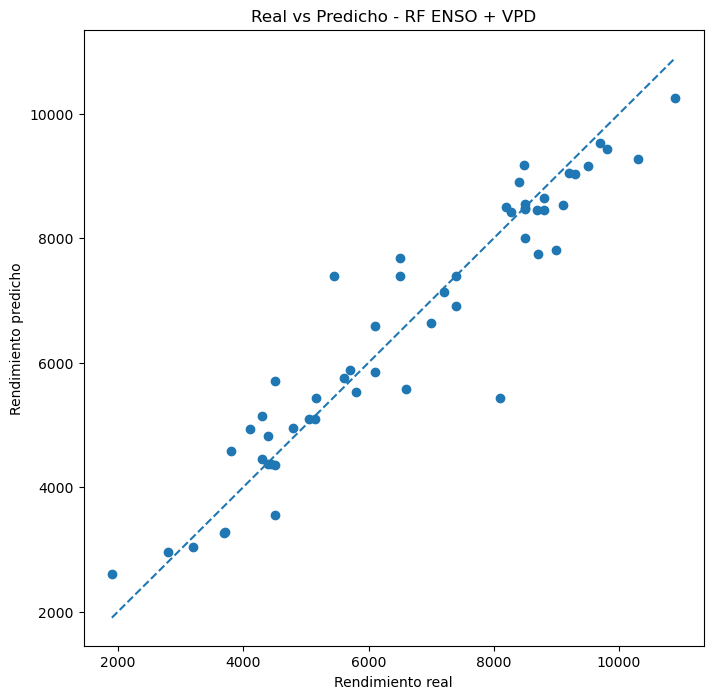

In [52]:
plt.figure(figsize=(8,8))

plt.scatter(
    y_test,
    predicciones_enso
)

plt.plot(

    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],

    linestyle="--"

)

plt.xlabel("Rendimiento real")

plt.ylabel("Rendimiento predicho")

plt.title(
    "Real vs Predicho - RF ENSO + VPD"
)

plt.show()

## Interpretación del gráfico Real vs Predicho

El análisis visual entre valores reales y predichos muestra que el modelo Random Forest presenta una buena capacidad de representación del rendimiento agrícola del maíz.

La mayoría de las observaciones se distribuyen próximas a la línea ideal de predicción, indicando una adecuada capacidad de generalización del sistema.

### Observaciones principales

- El modelo logra representar correctamente campañas de rendimiento bajo, medio y alto.
- La dispersión general de errores se mantiene moderada.
- No se observan patrones evidentes de sesgo sistemático.
- Los mayores errores aparecen principalmente en campañas extremas.

### Interpretación agroclimática

Las campañas extremas suelen estar asociadas a:
- sequías severas,
- excesos hídricos,
- olas de calor,
- y condiciones atmosféricas altamente variables.

Estos escenarios presentan una complejidad climática elevada y resultan naturalmente más difíciles de modelar.

Sin embargo, la incorporación de:
- ENSO,
- VPD,
- humedad relativa,
- y variables atmosféricas avanzadas

permitió mejorar considerablemente la representación de estos eventos.

### Conclusión

El modelo Random Forest mostró una capacidad predictiva robusta y una adecuada representación del sistema agroclimático del maíz.

Los resultados sugieren que la incorporación de variables climáticas avanzadas permitió capturar relaciones no lineales complejas entre:
- atmósfera,
- disponibilidad hídrica,
- variabilidad climática regional,
- y productividad agrícola.

## Importancia final de variables - Random Forest

Se analiza la importancia relativa de las variables dentro del modelo Random Forest final incorporando:

- ENSO,
- VPD,
- humedad relativa,
- variables atmosféricas,
- y calidad de suelo.

El objetivo es identificar los principales factores agroclimáticos que explican el rendimiento del maíz.

In [53]:
importancias_final = modelo_rf_enso.feature_importances_

In [54]:
importancias_final_df = pd.DataFrame({

    "Variable": X.columns,
    "Importancia": importancias_final

})

In [55]:
importancias_final_df = importancias_final_df.sort_values(

    by="Importancia",
    ascending=False

)

In [56]:
importancias_final_df

,Variable,Importancia
4,viento_kmh,0.485748
10,humedad_relativa_max,0.117752
2,precipitacion_mm,0.086344
9,humedad_relativa_prom,0.068092
1,temp_min_c,0.055926
8,score_suelo_promedio,0.050826
6,dias_lluvia,0.027256
11,humedad_relativa_min,0.027079
13,vpd_max,0.014232
14,vpd_min,0.013003


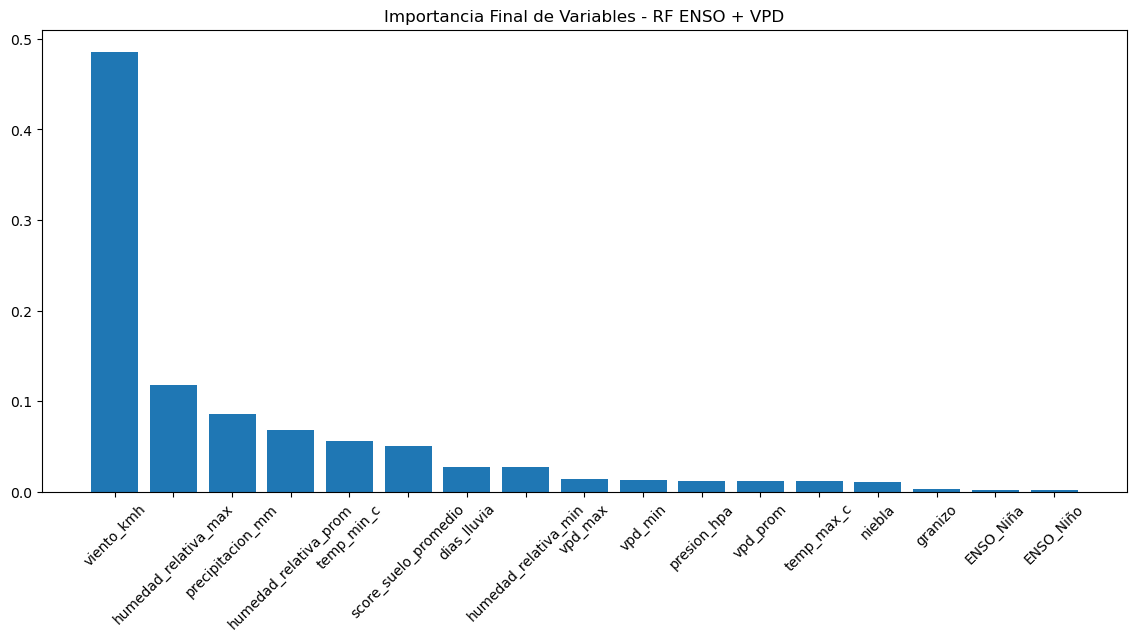

In [57]:
plt.figure(figsize=(14,6))

plt.bar(

    importancias_final_df["Variable"],
    importancias_final_df["Importancia"]

)

plt.title(
    "Importancia Final de Variables - RF ENSO + VPD"
)

plt.xticks(rotation=45)

plt.show()

## Interpretación final de importancia de variables

El análisis final de importancia de variables permitió identificar los principales factores agroclimáticos asociados al rendimiento del maíz.

### Variables dominantes

Las variables con mayor importancia dentro del modelo fueron:

1. velocidad del viento
2. humedad relativa máxima
3. precipitación acumulada
4. humedad relativa promedio
5. temperatura mínima
6. score de suelo

### Interpretación agroclimática

La velocidad del viento se mantuvo como la variable dominante en todas las versiones del modelo, sugiriendo que la demanda evaporativa atmosférica desempeña un rol central sobre la productividad del maíz.

Asimismo, la elevada importancia de humedad relativa máxima y precipitación acumulada refuerza la relevancia del balance hídrico-atmosférico dentro del sistema agroclimático.

Los resultados sugieren que procesos relacionados con:

- evapotranspiración,
- persistencia de humedad,
- estrés evaporativo,
- y disponibilidad hídrica

constituyen mecanismos clave para explicar el rendimiento agrícola.

### Sobre VPD y ENSO

Aunque las variables de VPD mostraron una fuerte significancia estadística en los modelos OLS, su importancia relativa dentro del Random Forest resultó moderada.

Esto probablemente se deba a la fuerte correlación física entre:
- VPD,
- humedad relativa,
- temperatura,
- y viento.

En modelos no lineales como Random Forest, estas variables tienden a compartir información predictiva.

Por otro lado, ENSO presentó una baja importancia directa dentro del modelo final.

Sin embargo, ENSO probablemente actúa de manera indirecta modificando:
- precipitación,
- humedad atmosférica,
- temperatura,
- y condiciones regionales de sequía o exceso hídrico.

### Conclusión general

El modelo final sugiere que el rendimiento del maíz está fuertemente condicionado por:

- demanda evaporativa atmosférica,
- persistencia de humedad,
- balance hídrico,
- y variabilidad climática regional.

Los resultados muestran una estructura agroclimática compleja donde las interacciones entre atmósfera, humedad y disponibilidad hídrica desempeñan un rol fundamental sobre la productividad agrícola.

## Backtesting temporal del modelo agroclimático final

Se implementa un procedimiento de validación temporal utilizando ventanas móviles con el objetivo de evaluar la robustez y capacidad de generalización del modelo agroclimático final.

En cada iteración:

- el modelo es entrenado utilizando campañas históricas previas,
- y posteriormente evaluado sobre campañas futuras no observadas.

Este enfoque permite simular escenarios predictivos más realistas y analizar el comportamiento del modelo frente a:

- campañas extremas,
- sequías,
- eventos ENSO,
- y variabilidad climática interanual.

In [58]:
dataset_bt = dataset_maiz_enso.sort_values(
    by="Campaña"
).reset_index(drop=True)

In [59]:
features = [

    "temp_max_c",
    "temp_min_c",

    "precipitacion_mm",

    "presion_hpa",

    "viento_kmh",

    "niebla",
    "dias_lluvia",
    "granizo",

    "score_suelo_promedio",

    "humedad_relativa_prom",
    "humedad_relativa_max",
    "humedad_relativa_min",

    "vpd_prom",
    "vpd_max",
    "vpd_min",

    "ENSO_Niña",
    "ENSO_Niño"

]

In [60]:
campañas = sorted(
    dataset_bt["Campaña"].unique()
)

In [61]:
resultados_bt = []

In [62]:
for i in range(15, len(campañas)-1):

    campañas_train = campañas[:i]

    campaña_test = campañas[i]

    train = dataset_bt[
        dataset_bt["Campaña"].isin(campañas_train)
    ]

    test = dataset_bt[
        dataset_bt["Campaña"] == campaña_test
    ]

    X_train = train[features]
    y_train = train["Rendimiento"]

    X_test = test[features]
    y_test = test["Rendimiento"]

    modelo_bt = RandomForestRegressor(

        n_estimators=300,
        random_state=42

    )

    modelo_bt.fit(X_train, y_train)

    pred = modelo_bt.predict(X_test)

    r2 = r2_score(y_test, pred)

    rmse = np.sqrt(
        mean_squared_error(y_test, pred)
    )

    resultados_bt.append({

        "campaña": campaña_test,
        "R2": r2,
        "RMSE": rmse

    })

In [63]:
bt_df = pd.DataFrame(resultados_bt)

In [64]:
bt_df

,campaña,R2,RMSE
0,1995/96,-16.161683,2548.633153
1,1996/97,0.184654,684.189296
2,1997/98,-20.050081,2091.132342
3,1998/99,-10.262112,1548.938917
4,1999/00,-0.993918,1952.536333
5,2000/01,-0.633341,1222.336885
6,2001/02,-4.516228,1398.831130
7,2002/03,-0.542724,1213.054668
8,2003/04,-116.412670,3134.510714
9,2004/05,-35.479885,1923.188766


## Resultados del backtesting temporal

Se realizó un procedimiento de validación temporal utilizando ventanas móviles con el objetivo de evaluar la capacidad de generalización del modelo agroclimático final frente a campañas futuras no observadas.

### Resultados generales

El modelo mostró un comportamiento heterogéneo entre campañas.

En algunas campañas se observaron resultados relativamente robustos, con errores moderados y valores positivos de R².

Sin embargo, también se identificaron campañas con:

- R² negativos,
- incrementos importantes del RMSE,
- y dificultades para representar campañas extremas.

### Interpretación de resultados

Estos resultados sugieren que, aunque el modelo presenta una elevada capacidad predictiva global, la representación temporal de campañas agrícolas extremas continúa siendo un desafío importante.

Las principales dificultades aparecen en escenarios asociados a:

- sequías severas,
- eventos ENSO intensos,
- cambios abruptos en precipitación,
- y condiciones atmosféricas altamente variables.

### Consideraciones metodológicas

El backtesting temporal constituye una validación mucho más exigente que una división aleatoria tradicional de entrenamiento y prueba.

En este enfoque:

- el modelo debe extrapolar condiciones climáticas futuras,
- muchas campañas presentan pocos registros,
- y la variabilidad interanual del sistema climático genera cambios estructurales complejos.

Asimismo, el coeficiente R² puede volverse extremadamente sensible cuando la variabilidad interna de una campaña es reducida.

Por este motivo, campañas con rendimientos relativamente homogéneos entre departamentos pueden producir valores negativos de R² incluso ante errores moderados.

### Aspectos positivos observados

A pesar de las dificultades temporales, el modelo logró:

- representar adecuadamente múltiples campañas,
- mantener errores moderados en varios períodos,
- y capturar relaciones agroclimáticas físicamente coherentes.

La incorporación de:
- ENSO,
- VPD,
- humedad relativa,
- y variables atmosféricas avanzadas

permitió mejorar la representación de procesos climáticos complejos y aumentar la robustez conceptual del sistema predictivo.

### Conclusión

Los resultados muestran que la predicción temporal del rendimiento agrícola continúa siendo un problema altamente desafiante debido a la naturaleza dinámica y extrema del sistema climático.

Sin embargo, el modelo desarrollado logró capturar relaciones agroclimáticas relevantes y construir una representación robusta del vínculo entre:

- atmósfera,
- disponibilidad hídrica,
- variabilidad climática regional,
- y productividad agrícola.

Estos resultados abren futuras líneas de investigación asociadas a:

- modelos específicos por régimen climático,
- segmentación ENSO,
- incorporación de nuevas variables extremas,
- y modelado temporal avanzado.

## Evolución temporal del desempeño predictivo

Se analiza la evolución temporal del desempeño del modelo mediante los valores de R² obtenidos en cada campaña del backtesting.

Este análisis permite identificar:
- períodos de mayor estabilidad,
- campañas extremas,
- y cambios en la capacidad predictiva del sistema.

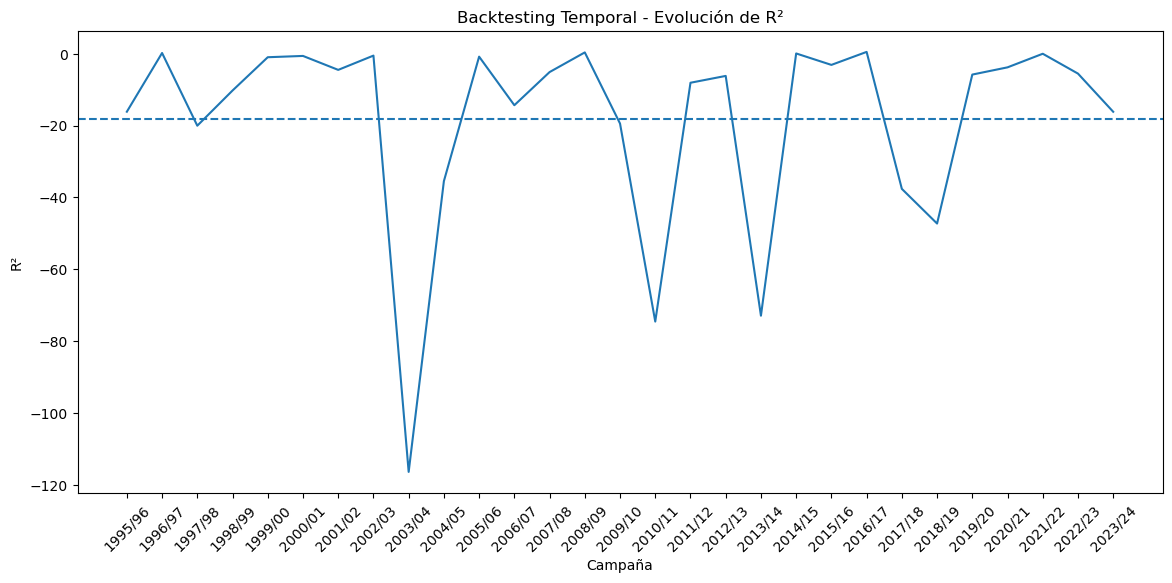

In [65]:
plt.figure(figsize=(14,6))

plt.plot(

    bt_df["campaña"],
    bt_df["R2"]

)

plt.axhline(

    bt_df["R2"].mean(),

    linestyle="--"

)

plt.xticks(rotation=45)

plt.title(
    "Backtesting Temporal - Evolución de R²"
)

plt.xlabel("Campaña")

plt.ylabel("R²")

plt.show()

## Interpretación de la evolución temporal del R²

El análisis temporal del coeficiente R² mostró un comportamiento altamente variable entre campañas agrícolas.

### Observaciones principales

Se identificaron campañas donde el modelo logró un desempeño relativamente estable, con valores de R² cercanos a cero o moderadamente positivos.

Sin embargo, también se observaron campañas con fuertes colapsos predictivos y valores muy negativos de R².

Las mayores dificultades aparecieron especialmente en campañas asociadas a:

- condiciones climáticas extremas,
- sequías severas,
- anomalías atmosféricas,
- y eventos ENSO intensos.

### Interpretación metodológica

Estos resultados muestran que el modelo presenta limitaciones importantes para extrapolar temporalmente escenarios climáticos futuros altamente variables.

El comportamiento observado es consistente con una de las principales limitaciones conocidas de modelos basados en Random Forest aplicados a series temporales:

- buena capacidad de ajuste general,
- pero dificultades para generalizar regímenes climáticos no observados previamente.

### Sensibilidad del R² en validación temporal

El coeficiente R² puede volverse extremadamente sensible cuando la variabilidad interna de una campaña es reducida.

En campañas donde los rendimientos presentan poca dispersión entre departamentos, pequeños errores absolutos pueden generar valores muy negativos de R².

Por este motivo, el R² temporal debe interpretarse junto con otras métricas como RMSE y análisis visuales del comportamiento predictivo.

### Aspectos positivos observados

A pesar de las dificultades temporales, el modelo logró:

- identificar relaciones agroclimáticas físicamente coherentes,
- representar correctamente múltiples campañas,
- y capturar el impacto de variables climáticas avanzadas como:
  - ENSO,
  - VPD,
  - humedad relativa,
  - y balance hídrico-atmosférico.

### Conclusión

Los resultados confirman que la predicción temporal del rendimiento agrícola constituye un problema altamente complejo debido a la dinámica extrema y no estacionaria del sistema climático.

Sin embargo, el modelo desarrollado permitió construir una representación agroclimática robusta y físicamente consistente de los principales factores que afectan la productividad del maíz.

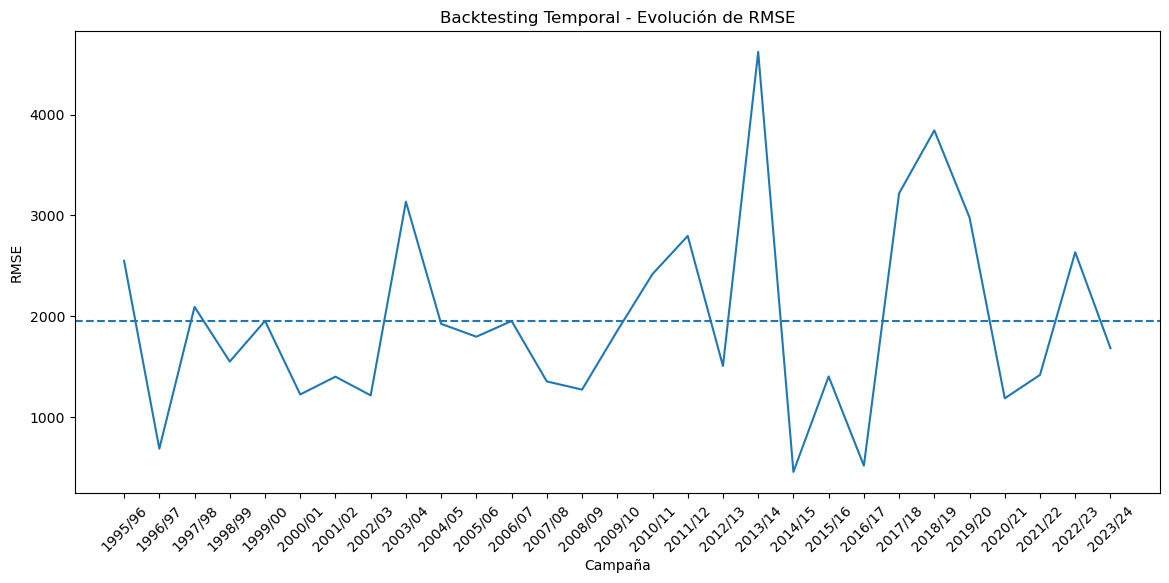

In [66]:
plt.figure(figsize=(14,6))

plt.plot(

    bt_df["campaña"],
    bt_df["RMSE"]

)

plt.axhline(

    bt_df["RMSE"].mean(),

    linestyle="--"

)

plt.xticks(rotation=45)

plt.title(
    "Backtesting Temporal - Evolución de RMSE"
)

plt.xlabel("Campaña")

plt.ylabel("RMSE")

plt.show()

## Interpretación de la evolución temporal del RMSE

El análisis temporal del RMSE mostró un comportamiento más estable que el observado en el coeficiente R².

### Observaciones principales

La mayoría de las campañas presentaron errores moderados dentro del rango esperado para un sistema agroclimático altamente variable.

En múltiples campañas el modelo logró mantener niveles relativamente estables de RMSE, indicando una adecuada capacidad de representación del rendimiento agrícola.

Sin embargo, también se identificaron campañas con incrementos importantes del error predictivo, especialmente asociadas a:

- eventos extremos,
- sequías severas,
- anomalías atmosféricas,
- y variabilidad climática intensa.

### Interpretación agroclimática

Las campañas con mayores errores probablemente correspondan a escenarios donde:

- el estrés hídrico fue particularmente severo,
- las precipitaciones presentaron comportamientos anómalos,
- o existieron cambios abruptos en las condiciones atmosféricas.

Estos escenarios representan algunos de los principales desafíos para los modelos predictivos agroclimáticos.

### Relación entre RMSE y R²

El RMSE mostró un comportamiento considerablemente más estable que el coeficiente R².

Esto sugiere que parte de los colapsos observados en R² estuvieron asociados a la sensibilidad estadística de esta métrica cuando la variabilidad interna de ciertas campañas resulta reducida.

Por este motivo, el análisis conjunto de:
- RMSE,
- R²,
- y comportamiento visual del modelo

permite obtener una evaluación más robusta del desempeño predictivo.

### Conclusión

Los resultados muestran que el modelo agroclimático logró mantener errores moderados en múltiples campañas, incluso bajo condiciones climáticas complejas.

La incorporación de:
- ENSO,
- VPD,
- humedad relativa,
- y variables atmosféricas avanzadas

permitió mejorar la representación física del sistema agrícola y construir un modelo predictivo robusto frente a escenarios climáticos variables.

# Conclusiones generales del modelo agroclimático avanzado de maíz

En este notebook se desarrolló una expansión avanzada del modelo agroclimático de maíz incorporando variables atmosféricas y climáticas de mayor complejidad.

Particularmente se integraron:

- humedad relativa,
- déficit de presión de vapor (VPD),
- ENSO,
- y variables atmosféricas derivadas.

## Principales resultados obtenidos

### Modelos OLS

La incorporación progresiva de variables climáticas avanzadas permitió mejorar significativamente la capacidad explicativa de los modelos lineales.

El modelo final alcanzó:

- R² ≈ 0.69

mostrando una mejora sustancial respecto a las versiones iniciales del sistema.

Las variables más relevantes fueron:

- VPD,
- humedad relativa,
- viento,
- precipitación,
- temperatura,
- y ENSO.

## Modelos Random Forest

El modelo Random Forest final alcanzó:

- R² ≈ 0.90

mostrando una elevada capacidad predictiva y una adecuada representación de relaciones no lineales complejas.

El análisis de importancia de variables mostró que los principales factores asociados al rendimiento del maíz fueron:

- velocidad del viento,
- humedad atmosférica,
- precipitación,
- temperatura mínima,
- y calidad de suelo.

## Interpretación agroclimática

Los resultados obtenidos sugieren que el rendimiento del maíz en el sur de Santa Fe está fuertemente condicionado por:

- balance hídrico-atmosférico,
- demanda evaporativa,
- persistencia de humedad,
- variabilidad climática regional,
- y estrés ambiental.

Variables como:

- VPD,
- humedad relativa,
- y viento

permitieron representar procesos fisiológicos asociados a:

- evapotranspiración,
- cierre estomático,
- pérdida de humedad,
- y estrés hídrico del cultivo.

Asimismo, ENSO permitió capturar parte de la variabilidad climática regional asociada a campañas húmedas y secas.

## Validación temporal

El backtesting temporal mostró que la predicción agrícola interanual continúa siendo un desafío altamente complejo.

El modelo logró mantener errores moderados en múltiples campañas, aunque presentó dificultades frente a escenarios climáticos extremos y regímenes atmosféricos particularmente anómalos.

Estos resultados reflejan la naturaleza dinámica y no estacionaria del sistema climático agrícola.

## Aportes del notebook

Este notebook permitió:

- expandir significativamente el modelo agroclimático de maíz,
- incorporar variables atmosféricas avanzadas,
- analizar procesos de estrés evaporativo,
- evaluar variabilidad climática regional,
- y construir un sistema predictivo más robusto y físicamente consistente.

## Líneas futuras de trabajo

Los resultados obtenidos abren nuevas líneas de investigación asociadas a:

- modelos específicos por régimen ENSO,
- segmentación climática,
- incorporación de humedad de suelo,
- olas de calor,
- anomalías intraestacionales,
- modelos temporales avanzados,
- y sistemas predictivos multicultivo integrados.

In [68]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split

features_maiz = [

    "temp_max_c",
    "temp_min_c",
    "precipitacion_mm",
    "presion_hpa",
    "viento_kmh",
    "niebla",
    "dias_lluvia",
    "granizo",
    "score_suelo_promedio",
    "humedad_relativa_prom",
    "humedad_relativa_max",
    "humedad_relativa_min"

]

X = dataset_maiz[features_maiz]
y = dataset_maiz["Rendimiento"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

modelo_rf_final = RandomForestRegressor(
    n_estimators=500,
    random_state=42
)

modelo_rf_final.fit(X_train, y_train)

predicciones = modelo_rf_final.predict(X_test)

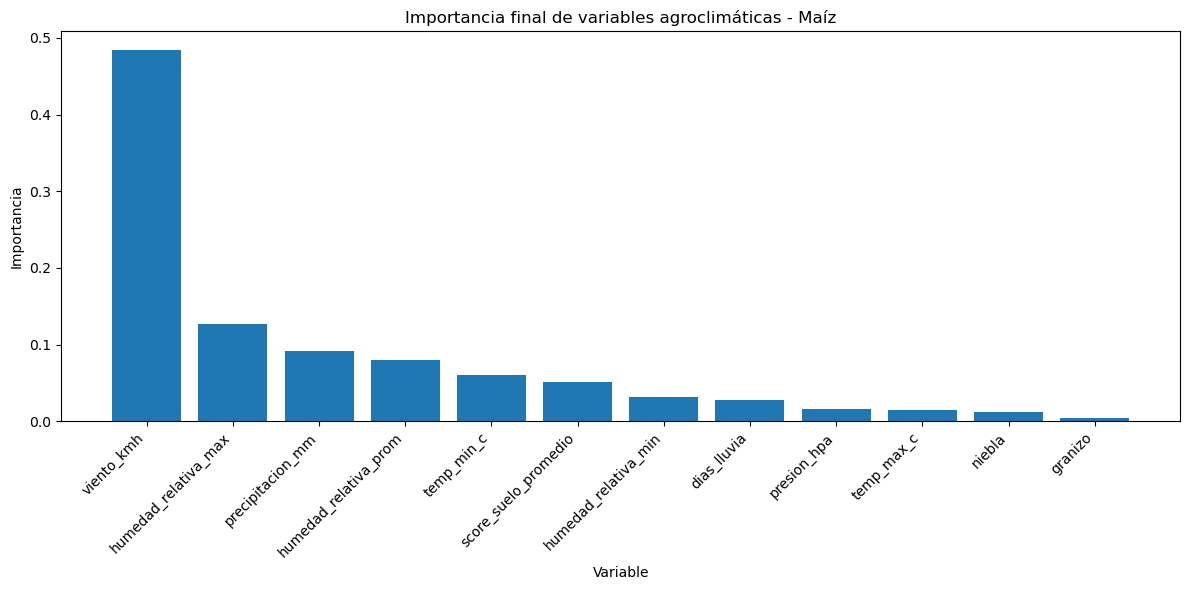

In [69]:
importancias_maiz = pd.DataFrame({

    "Variable": X.columns,
    "Importancia": modelo_rf_final.feature_importances_

}).sort_values(
    by="Importancia",
    ascending=False
)

plt.figure(figsize=(12,6))

plt.bar(
    importancias_maiz["Variable"],
    importancias_maiz["Importancia"]
)

plt.title("Importancia final de variables agroclimáticas - Maíz")
plt.xlabel("Variable")
plt.ylabel("Importancia")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

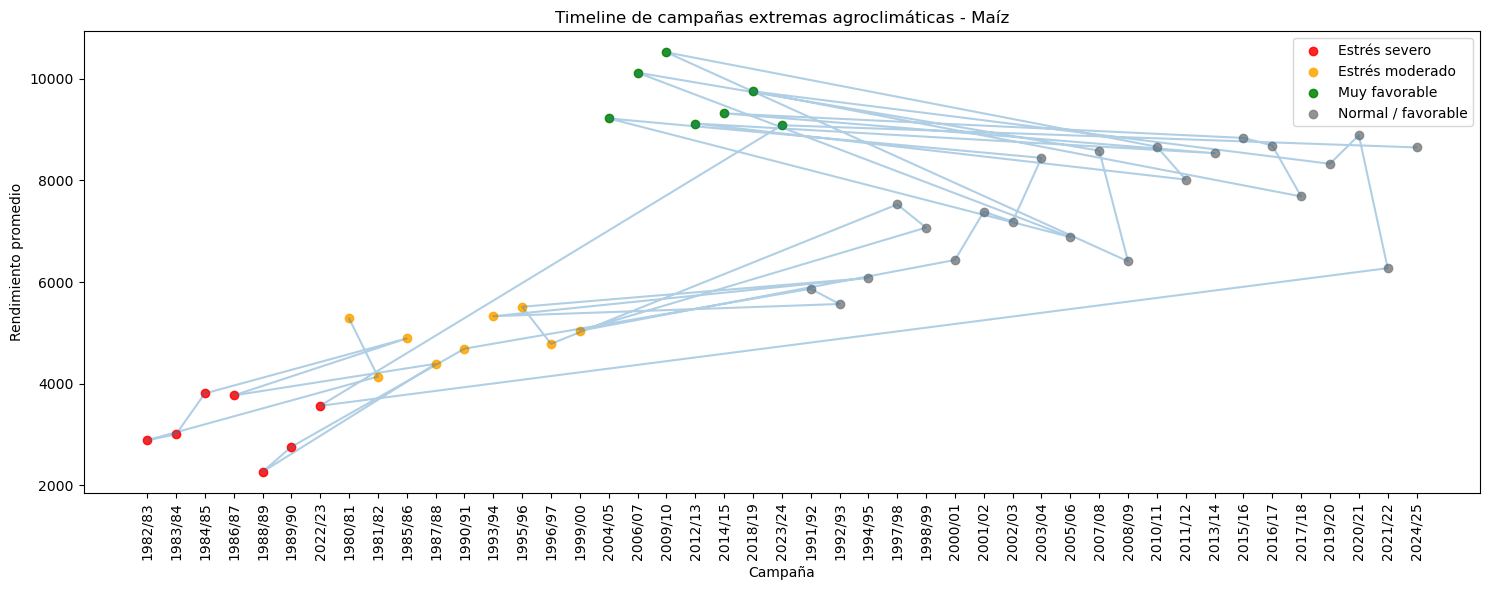

In [70]:
maiz_timeline = dataset_maiz.groupby("Campaña").agg({

    "Rendimiento": "mean"

}).reset_index()

maiz_timeline["tipo_campaña"] = "Normal / favorable"

maiz_timeline.loc[
    maiz_timeline["Rendimiento"] <= maiz_timeline["Rendimiento"].quantile(0.15),
    "tipo_campaña"
] = "Estrés severo"

maiz_timeline.loc[
    (maiz_timeline["Rendimiento"] > maiz_timeline["Rendimiento"].quantile(0.15)) &
    (maiz_timeline["Rendimiento"] <= maiz_timeline["Rendimiento"].quantile(0.35)),
    "tipo_campaña"
] = "Estrés moderado"

maiz_timeline.loc[
    maiz_timeline["Rendimiento"] >= maiz_timeline["Rendimiento"].quantile(0.85),
    "tipo_campaña"
] = "Muy favorable"

colores = {
    "Estrés severo": "red",
    "Estrés moderado": "orange",
    "Muy favorable": "green",
    "Normal / favorable": "gray"
}

plt.figure(figsize=(15,6))

for tipo, color in colores.items():

    datos = maiz_timeline[
        maiz_timeline["tipo_campaña"] == tipo
    ]

    plt.scatter(
        datos["Campaña"],
        datos["Rendimiento"],
        color=color,
        label=tipo,
        alpha=0.85
    )

plt.plot(
    maiz_timeline["Campaña"],
    maiz_timeline["Rendimiento"],
    alpha=0.35
)

plt.title("Timeline de campañas extremas agroclimáticas - Maíz")
plt.xlabel("Campaña")
plt.ylabel("Rendimiento promedio")

plt.xticks(rotation=90)
plt.legend()
plt.tight_layout()

plt.savefig(
    "../../Dashboard/timeline_campañas_extremas_maiz.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

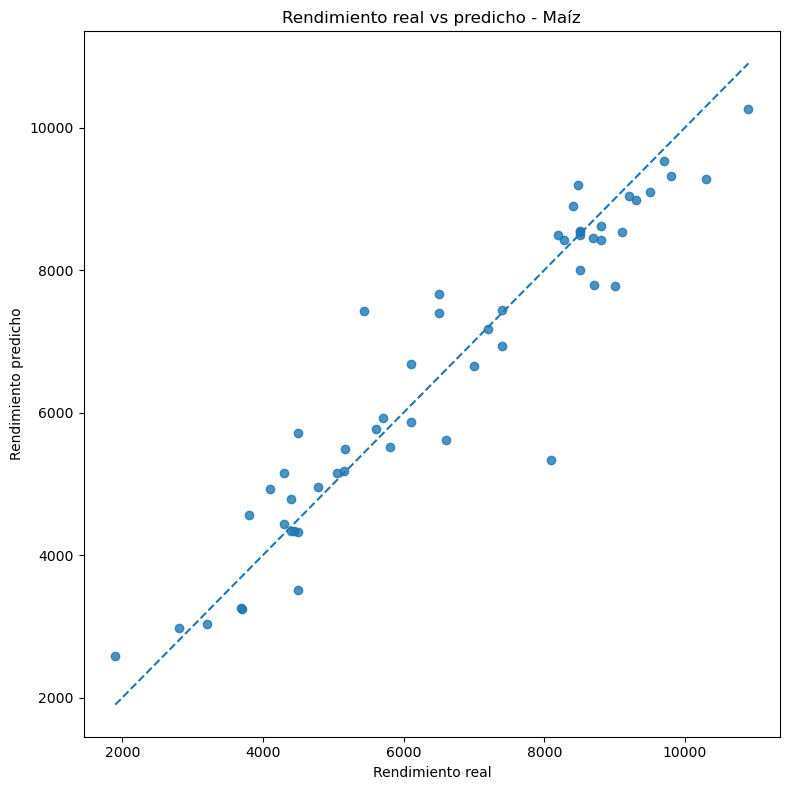

In [71]:
resultados_pred_maiz = pd.DataFrame({

    "Real": y_test.values,
    "Predicho": predicciones

})

plt.figure(figsize=(8,8))

plt.scatter(
    resultados_pred_maiz["Real"],
    resultados_pred_maiz["Predicho"],
    alpha=0.8
)

plt.plot(
    [
        resultados_pred_maiz["Real"].min(),
        resultados_pred_maiz["Real"].max()
    ],
    [
        resultados_pred_maiz["Real"].min(),
        resultados_pred_maiz["Real"].max()
    ],
    linestyle="--"
)

plt.title("Rendimiento real vs predicho - Maíz")
plt.xlabel("Rendimiento real")
plt.ylabel("Rendimiento predicho")

plt.tight_layout()

plt.savefig(
    "../../Dashboard/real_vs_predicho_maiz.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

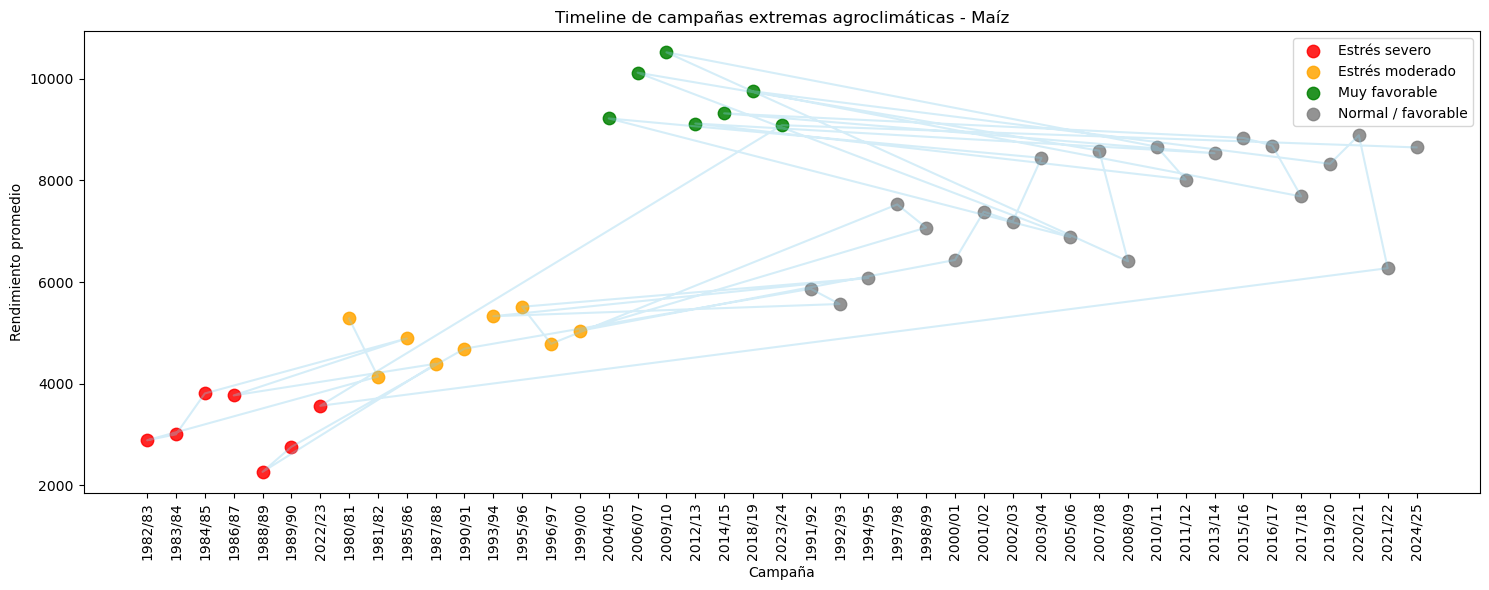

In [72]:
# Timeline de campañas extremas agroclimáticas - Maíz

maiz_timeline = dataset_maiz.groupby("Campaña").agg({

    "Rendimiento": "mean"

}).reset_index()

# Ordenar campañas cronológicamente

maiz_timeline = maiz_timeline.sort_values(
    by="Campaña"
)

# Clasificación de campañas

maiz_timeline["tipo_campaña"] = "Normal / favorable"

maiz_timeline.loc[
    maiz_timeline["Rendimiento"] <= maiz_timeline["Rendimiento"].quantile(0.15),
    "tipo_campaña"
] = "Estrés severo"

maiz_timeline.loc[
    (
        maiz_timeline["Rendimiento"] > maiz_timeline["Rendimiento"].quantile(0.15)
    ) &
    (
        maiz_timeline["Rendimiento"] <= maiz_timeline["Rendimiento"].quantile(0.35)
    ),
    "tipo_campaña"
] = "Estrés moderado"

maiz_timeline.loc[
    maiz_timeline["Rendimiento"] >= maiz_timeline["Rendimiento"].quantile(0.85),
    "tipo_campaña"
] = "Muy favorable"

# Colores

colores = {

    "Estrés severo": "red",
    "Estrés moderado": "orange",
    "Muy favorable": "green",
    "Normal / favorable": "gray"

}

# Gráfico

plt.figure(figsize=(15,6))

for tipo, color in colores.items():

    datos = maiz_timeline[
        maiz_timeline["tipo_campaña"] == tipo
    ]

    plt.scatter(
        datos["Campaña"],
        datos["Rendimiento"],
        color=color,
        label=tipo,
        alpha=0.85,
        s=80
    )

# Línea temporal

plt.plot(
    maiz_timeline["Campaña"],
    maiz_timeline["Rendimiento"],
    color="skyblue",
    alpha=0.35
)

# Títulos

plt.title(
    "Timeline de campañas extremas agroclimáticas - Maíz"
)

plt.xlabel("Campaña")
plt.ylabel("Rendimiento promedio")

plt.xticks(rotation=90)

plt.legend()

plt.tight_layout()

# Guardar gráfico

plt.savefig(
    "../../Dashboard/timeline_campañas_extremas_maiz.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

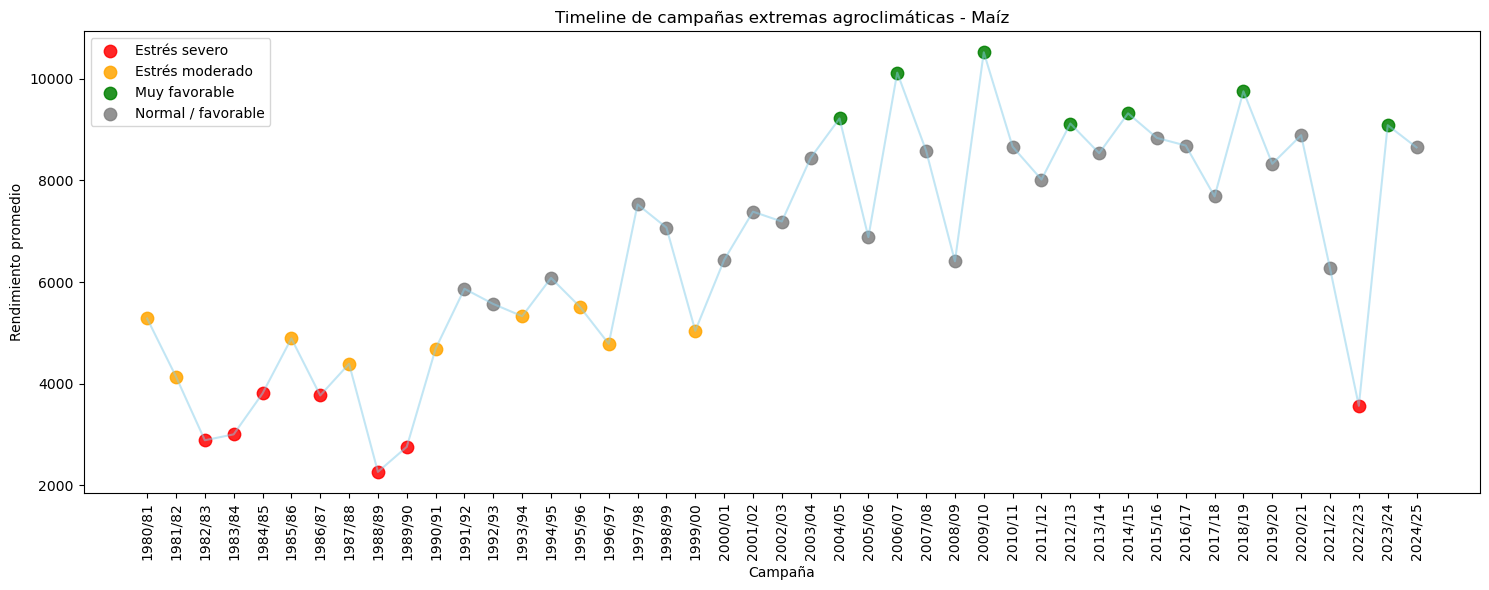

In [73]:
# Timeline de campañas extremas agroclimáticas - Maíz

maiz_timeline = dataset_maiz.groupby("Campaña").agg({
    "Rendimiento": "mean"
}).reset_index()

# Crear año inicial de campaña para ordenar correctamente
maiz_timeline["año_inicio"] = (
    maiz_timeline["Campaña"]
    .str.split("/")
    .str[0]
    .astype(int)
)

maiz_timeline = maiz_timeline.sort_values(
    by="año_inicio"
)

# Clasificación de campañas
maiz_timeline["tipo_campaña"] = "Normal / favorable"

maiz_timeline.loc[
    maiz_timeline["Rendimiento"] <= maiz_timeline["Rendimiento"].quantile(0.15),
    "tipo_campaña"
] = "Estrés severo"

maiz_timeline.loc[
    (maiz_timeline["Rendimiento"] > maiz_timeline["Rendimiento"].quantile(0.15)) &
    (maiz_timeline["Rendimiento"] <= maiz_timeline["Rendimiento"].quantile(0.35)),
    "tipo_campaña"
] = "Estrés moderado"

maiz_timeline.loc[
    maiz_timeline["Rendimiento"] >= maiz_timeline["Rendimiento"].quantile(0.85),
    "tipo_campaña"
] = "Muy favorable"

colores = {
    "Estrés severo": "red",
    "Estrés moderado": "orange",
    "Muy favorable": "green",
    "Normal / favorable": "gray"
}

plt.figure(figsize=(15,6))

# Línea temporal ordenada
plt.plot(
    maiz_timeline["año_inicio"],
    maiz_timeline["Rendimiento"],
    color="skyblue",
    alpha=0.5
)

# Puntos por categoría
for tipo, color in colores.items():
    datos = maiz_timeline[maiz_timeline["tipo_campaña"] == tipo]

    plt.scatter(
        datos["año_inicio"],
        datos["Rendimiento"],
        color=color,
        label=tipo,
        alpha=0.85,
        s=80
    )

plt.title("Timeline de campañas extremas agroclimáticas - Maíz")
plt.xlabel("Campaña")
plt.ylabel("Rendimiento promedio")

plt.xticks(
    maiz_timeline["año_inicio"],
    maiz_timeline["Campaña"],
    rotation=90
)

plt.legend()
plt.tight_layout()

plt.savefig(
    "../../Dashboard/timeline_campañas_extremas_maiz.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()